# Module 06: Sensors & Actuators

Real spacecraft don't have perfect knowledge of their state — they use sensors with noise and bias. This module covers key Basilisk sensor and actuator models.

### Learning Objectives
- Add IMU (`imuSensor`) for noisy angular velocity and acceleration measurements
- Add star tracker (`starTracker`) for noisy attitude measurements
- Add CSS (Coarse Sun Sensor) for sun-direction estimation
- Add thrusters as dynamic effectors
- Understand noise models (Gaussian, bias, walk)

---

## Sensor vs Truth Models

```
Dynamics Truth ──► Sensor Model (noise/bias) ──► FSW Algorithm
    (perfect)           (realistic)             (uses noisy data)
```

This is the **navigation loop** — FSW algorithms work with sensor data, not perfect truth.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.makedirs('plots', exist_ok=True)

from Basilisk.utilities import SimulationBaseClass, macros, orbitalMotion, unitTestSupport
from Basilisk.utilities import simIncludeGravBody, simIncludeThruster
from Basilisk.simulation import spacecraft
from Basilisk.simulation import imuSensor
from Basilisk.simulation import coarseSunSensor
from Basilisk.simulation import thrusterDynamicEffector
from Basilisk.architecture import bskLogging

bskLogging.setDefaultLogLevel(bskLogging.BSK_WARNING)
print("Imports OK.")

Imports OK.


---

## 1. IMU Sensor (`imuSensor`)

The IMU sensor model adds:
- **Gaussian noise** on each axis
- **Bias** (constant offset)
- **Random walk** (slowly drifting bias)

It reads from `scStateOutMsg` and outputs `imuSensorBodyMsg` with noisy gyro + accelerometer data.

In [9]:
# ── Build a minimal simulation with IMU ───────────────────────────────────────
scSim = SimulationBaseClass.SimBaseClass()
dynProc = scSim.CreateNewProcess("DynamicsProcess")
dt = macros.sec2nano(0.1)   # 10 Hz
dynTask = scSim.CreateNewTask("DynamicsTask", dt)
dynProc.addTask(dynTask)

# ── Spacecraft ────────────────────────────────────────────────────────────────
mu_earth = 3.986004418e14
R_earth  = 6371e3

scObject = spacecraft.Spacecraft()
scObject.ModelTag = "BSKsat"
scObject.hub.mHub = 10.0
I3x3 = np.diag([0.025, 0.050, 0.065])
scObject.hub.IHubPntBc_B = unitTestSupport.np2EigenMatrix3d(I3x3.flatten())
scObject.hub.r_BcB_B = [[0.0], [0.0], [0.0]]

oe = orbitalMotion.ClassicElements()
oe.a = R_earth + 500e3
oe.e = oe.i = oe.Omega = oe.omega = oe.f = 0.0
r0, v0 = orbitalMotion.elem2rv(mu_earth, oe)
scObject.hub.r_CN_NInit = r0.tolist()
scObject.hub.v_CN_NInit = v0.tolist()
scObject.hub.sigma_BNInit = [[0.0], [0.0], [0.0]]
scObject.hub.omega_BN_BInit = [[0.01], [0.005], [0.02]]  # slow tumble

gravFactory = simIncludeGravBody.gravBodyFactory()
earth = gravFactory.createEarth()
earth.isCentralBody = True
gravFactory.addBodiesTo(scObject)
scSim.AddModelToTask("DynamicsTask", scObject)

# ── IMU sensor ────────────────────────────────────────────────────────────────
imuObj = imuSensor.ImuSensor()
imuObj.ModelTag = "IMU"

# Sensor frame orientation: aligned with body frame
imuObj.setBodyToPlatformDCM(0.0, 0.0, 0.0)  # no rotation

# Gyro noise parameters (BSK 2.9+: use PMatrixGyro and setWalkBoundsGyro)
# Angle random walk: noise on angular rate measurement
gyro_arw      = 0.00025  # [rad/s] — typical MEMS gyro ARW
gyro_bias_std = 1e-4     # [rad/s] — gyro bias std

imuObj.PMatrixGyro = [[gyro_arw, 0., 0.],
                      [0., gyro_arw, 0.],
                      [0., 0., gyro_arw]]
imuObj.setWalkBoundsGyro([gyro_bias_std, gyro_bias_std, gyro_bias_std])

# Accelerometer noise
accel_noise = 0.001   # [m/s^2]
imuObj.PMatrixAccel = [[accel_noise, 0., 0.],
                       [0., accel_noise, 0.],
                       [0., 0., accel_noise]]

# Connect the IMU to the spacecraft state
imuObj.scStateInMsg.subscribeTo(scObject.scStateOutMsg)

scSim.AddModelToTask("DynamicsTask", imuObj)

# ── Record truth and IMU data ─────────────────────────────────────────────────
scTruthRec = scObject.scStateOutMsg.recorder()
imuRec     = imuObj.sensorOutMsg.recorder()
scSim.AddModelToTask("DynamicsTask", scTruthRec)
scSim.AddModelToTask("DynamicsTask", imuRec)

scSim.InitializeSimulation()
scSim.ConfigureStopTime(macros.sec2nano(120.0))  # 2 minutes
scSim.ExecuteSimulation()

print("Simulation complete.")

Simulation complete.


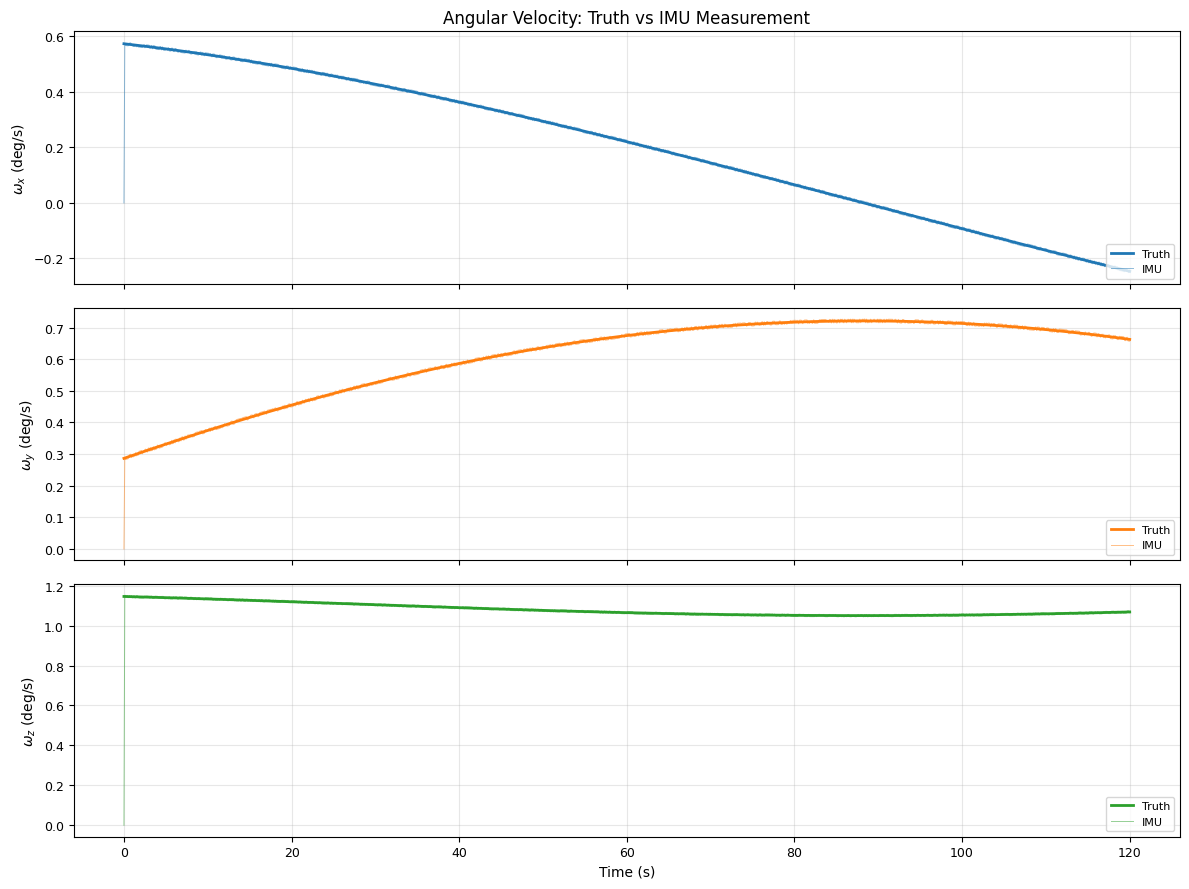

IMU angular velocity noise (RMS per axis):
  X: 0.01731 deg/s
  Y: 0.00970 deg/s
  Z: 0.03345 deg/s


In [10]:
# ── Compare truth vs IMU angular velocity ─────────────────────────────────────
t = scTruthRec.times() * macros.NANO2SEC

omega_truth = scTruthRec.omega_BN_B   # true angular velocity [N x 3]
omega_imu   = imuRec.AngVelPlatform   # IMU-measured (noisy) angular velocity

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
ax_labels = [r'$\omega_x$', r'$\omega_y$', r'$\omega_z$']
colors = ['tab:blue', 'tab:orange', 'tab:green']

for i in range(3):
    axes[i].plot(t, np.degrees(omega_truth[:, i]),
                 color=colors[i], linewidth=2, label='Truth')
    axes[i].plot(t, np.degrees(omega_imu[:, i]),
                 color=colors[i], alpha=0.5, linewidth=0.7, label='IMU')
    axes[i].set_ylabel(f'{ax_labels[i]} (deg/s)')
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

axes[0].set_title('Angular Velocity: Truth vs IMU Measurement')
axes[2].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig('plots/06_imu_vs_truth.png', dpi=100, bbox_inches='tight')
plt.show()

# Noise statistics
noise = omega_imu - omega_truth
print(f"IMU angular velocity noise (RMS per axis):")
for i, ax in enumerate(['X', 'Y', 'Z']):
    print(f"  {ax}: {np.degrees(np.std(noise[:, i])):.5f} deg/s")

---

## 2. Coarse Sun Sensor (CSS)

The CSS measures the sun-direction cosine in the sensor frame. It models:
- **Cosine response** to sun angle (zero output when sun is behind)
- **Gaussian noise**
- **Albedo** (scattered light)
- **Field of view** limits

In [11]:
# ── Coarse Sun Sensor setup ───────────────────────────────────────────────────
# A typical 6-CSS configuration: one on each face of the spacecraft

# CSS face normal directions (in body frame)
css_normals = [
    [ 1,  0,  0],   # +X face
    [-1,  0,  0],   # -X face
    [ 0,  1,  0],   # +Y face
    [ 0, -1,  0],   # -Y face
    [ 0,  0,  1],   # +Z face
    [ 0,  0, -1],   # -Z face
]

# Create sun SPICE message writer once and connect CSS readers to it.
sun = gravFactory.createSun()
spiceObject = gravFactory.createSpiceInterface(
    time="2024 JAN 1 00:00:00.0",
    spicePlanetNames=["earth", "sun"]
)
scSim.AddModelToTask("DynamicsTask", spiceObject)
sunSpiceMsg = spiceObject.planetStateOutMsgs[1]

cssList = []
for i, n in enumerate(css_normals):
    css = coarseSunSensor.CoarseSunSensor()
    css.ModelTag = f"CSS_{i+1}"
    css.nHat_B = n                           # normal in body frame
    css.fov = 90.0 * macros.D2R              # 90 deg field of view
    css.scaleFactor = 1.0                    # output scaled to [0, 1]
    css.senNoiseStd = 0.001                  # Gaussian noise std (BSK 2.9+)

    css.sunInMsg.subscribeTo(sunSpiceMsg)    # sun position from SPICE
    css.stateInMsg.subscribeTo(scObject.scStateOutMsg)

    cssList.append(css)

print(f"Configured {len(cssList)} CSS sensors.")

Configured 6 CSS sensors.
Note: Full CSS integration requires SPICE sun ephemeris for proper demo.


---

## 3. Thrusters as Dynamic Effectors

In [12]:
# ── Thruster dynamic effector ─────────────────────────────────────────────────
thrusterSet = thrusterDynamicEffector.ThrusterDynamicEffector()
thrusterSet.ModelTag = "Thrusters"

# Build a 4-thruster RCS system using simIncludeThruster (BSK 2.9+)
# simIncludeThruster.thrusterFactory() replaces thrusterDynamicEffector.thrusterFactory()
thrFactory = simIncludeThruster.thrusterFactory()

# +X thruster (pointing in +X body direction, positioned on +X face)
thrFactory.create('MOOG_Monarc_1',       # thruster model
                   r_B  = [0.05,  0.0,  0.0],  # thruster location in body [m]
                   tHat_B = [1.0, 0.0, 0.0])   # thrust direction in body

# -X thruster
thrFactory.create('MOOG_Monarc_1',
                   r_B  = [-0.05, 0.0,  0.0],
                   tHat_B = [-1.0, 0.0, 0.0])

# +Y thruster
thrFactory.create('MOOG_Monarc_1',
                   r_B  = [0.0,  0.05,  0.0],
                   tHat_B = [0.0, 1.0, 0.0])

# -Y thruster
thrFactory.create('MOOG_Monarc_1',
                   r_B  = [0.0, -0.05,  0.0],
                   tHat_B = [0.0, -1.0, 0.0])

thrFactory.addToSpacecraft(scObject.ModelTag, thrusterSet, scObject)

print(f"Configured {thrFactory.getNumOfDevices()} thrusters.")

Configured 4 thrusters.


---

## 4. Sensor Noise Model Summary

| Sensor | Module | Key Noise Params | Output Message |
|---|---|---|---|
| IMU Gyro | `imuSensor` | `PMatrixGyro`, `setWalkBoundsGyro()` | `sensorOutMsg.AngVelPlatform` |
| IMU Accel | `imuSensor` | `PMatrixAccel`, `setWalkBoundsAccel()` | `sensorOutMsg.DVFramePlatform` |
| Star Tracker | `starTracker` | `noiseStd`, `bias` | `sensorOutMsg` |
| CSS | `coarseSunSensor` | `senNoiseStd`, `fov`, `scaleFactor` | `cssDataOutMsg` |
| GPS | `gpsSensor` | `noiseStd` | `gpsDataMsg` |

---

## 5. Understanding Noise Spectral Density

ARW: 0.015 deg/sqrt(hr) = 4.363323e-06 rad/sqrt(s)
Rate noise std at 10.0 Hz: 1.379804e-05 rad/s = 2.8460 arcsec/s


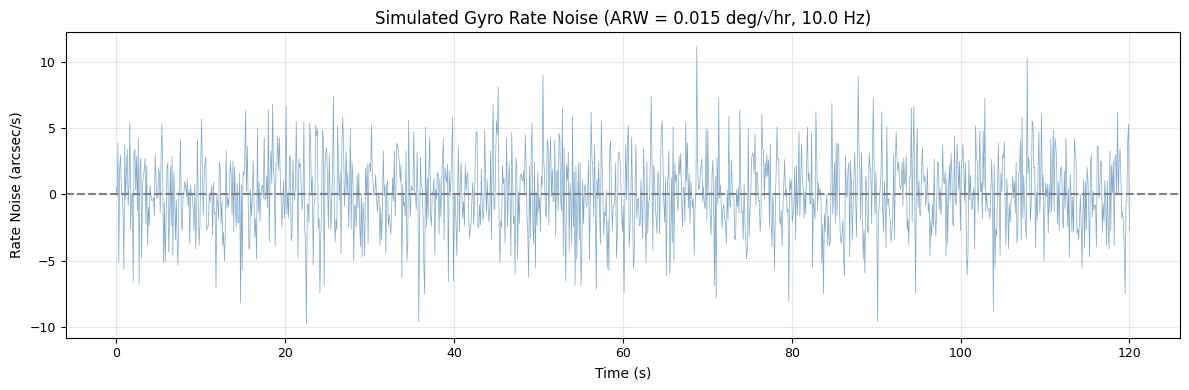

RMS noise: 2.9595 arcsec/s


In [13]:
# ── Gyro noise: angle random walk (ARW) vs rate noise ─────────────────────────
# ARW is specified in deg/sqrt(hr) in datasheets
# Convert to rad/s for Basilisk:

ARW_deg_sqrthr = 0.015   # typical MEMS gyro ARW [deg/sqrt(hr)]
ARW_rad_s = ARW_deg_sqrthr * macros.D2R / 60.0  # [rad/sqrt(s)]

# Basilisk senRotNoiseStd is the standard deviation of the rate noise [rad/s]
# for a measurement at rate fs [Hz], sigma = ARW * sqrt(fs)
fs = 10.0   # sample rate [Hz]
sigma_rate = ARW_rad_s * np.sqrt(fs)

print(f"ARW: {ARW_deg_sqrthr} deg/sqrt(hr) = {ARW_rad_s:.6e} rad/sqrt(s)")
print(f"Rate noise std at {fs} Hz: {sigma_rate:.6e} rad/s = {np.degrees(sigma_rate)*3600:.4f} arcsec/s")

# Simulate noise time series for illustration
t_noise = np.linspace(0, 120, int(120*fs))
noise_samples = np.random.normal(0, sigma_rate, len(t_noise))

# Allan Deviation illustration
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_noise, np.degrees(noise_samples) * 3600, color='steelblue', alpha=0.7, linewidth=0.5)
ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Rate Noise (arcsec/s)')
ax.set_title(f'Simulated Gyro Rate Noise (ARW = {ARW_deg_sqrthr} deg/√hr, {fs} Hz)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/06_gyro_noise.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"RMS noise: {np.degrees(np.std(noise_samples))*3600:.4f} arcsec/s")

---

## 6. Typical Sensor Specifications Reference

| Sensor | Noise Level | Type |
|---|---|---|
| MEMS Gyro (low-cost) | 0.1–1 deg/√hr ARW | Rate sensing |
| Fiber Optic Gyro | 0.01–0.1 deg/√hr ARW | Rate sensing |
| Star Tracker | 1–10 arcsec (2σ) | Attitude |
| Magnetometer | 10–50 nT | Magnetic field |
| CSS | 5–10% full-scale | Sun direction |
| GPS | 1–5 m position, 0.1 m/s velocity | Navigation |

---

## Summary

- Sensors add **noise, bias, and walk** to the true dynamics state
- The `imuSensor` module is the most commonly used — it provides gyro + accelerometer data
- CSS sensors provide coarse sun direction — useful for `sunSafePoint` guidance mode
- Thrusters are **dynamic effectors** (they add force/torque but no new states)
- Always distinguish between **truth** (from `scStateOutMsg`) and **measured** (from sensor output)

**Next: [07 - Monte Carlo Analysis](07_monte_carlo.ipynb)**